# Frontier Model Benchmark â€” GPT-5-mini on Granulometry

Before using a frontier model to generate training data (Task 4 SEAL approach),
verify it can actually classify these images correctly.

Tests GPT-5-mini (Azure OpenAI) on the same 108 test images, zero-shot and few-shot.
Compares against Qwen2.5-VL-3B baseline from the main benchmark.

## Setup

In [1]:
import os, json, re, time, base64
import numpy as np
from PIL import Image
from collections import defaultdict, Counter
import matplotlib.pyplot as plt

# !pip install openai -q  # uncomment if not installed


## Config

In [23]:
from openai import AzureOpenAI

TEST_DIR = '../../datasets/granulometry/test'
MANIFEST = '../../datasets/granulometry/test_manifest.json'
REF_IMAGE_PATH = 'examples_classification_data.png'

# Azure OpenAI â€” GPT-5-mini
AZURE_ENDPOINT = 'https://ether-project-resource.openai.azure.com/'
DEPLOYMENT = 'gpt-5' #'gpt-5-pro' gpt-5-mini
API_VERSION = '2024-12-01-preview'
# API_KEY = os.environ.get('AZURE_OPENAI_API_KEY', '')  # set below or via env
API_KEY = os.environ.get('AZURE_OPENAI_API_KEY', '')  # set via env

# Uncomment and set your key:
# API_KEY = 'your-key-here'

client = AzureOpenAI(
    azure_endpoint=AZURE_ENDPOINT,
    api_key=API_KEY,
    api_version=API_VERSION,
)

print(f'Endpoint: {AZURE_ENDPOINT}')
print(f'Deployment: {DEPLOYMENT}')
print(f'API key set: {bool(API_KEY)}')


Endpoint: https://ether-project-resource.openai.azure.com/
Deployment: gpt-5
API key set: True


## Prompts

In [24]:
PROMPT_ZS = '''This is a top-down photo of concrete aggregate. GSD = 8.0 px/mm.

Classify it on two axes:

MAX PARTICLE SIZE - estimate the largest stone, round to 8, 16, or 32 mm.
Reference: at 8.0 px/mm, a 8mm stone = ~64px wide, 16mm = ~128px, 32mm = ~256px.

GRADING - describes size distribution (not absolute size):
- COARSE: most particles similar size, close to max. Few small particles. Uniform texture.
- MEDIUM: moderate mix of large and small.
- FINE: wide range of sizes. Many small particles fill gaps between larger ones. Dense, packed.

Respond with ONLY a JSON object:
{"max_particle_size_mm": <8|16|32>, "grading": "<coarse|medium|fine>"}'''

PROMPT_FS_REF = '''First image: reference chart. 3x3 grid of concrete aggregate photos.
COLUMNS (left to right) = max particle size: 8mm | 16mm | 32mm
ROWS (top to bottom) = grading: A (coarse) | B (medium) | C (fine)

Grading = size DISTRIBUTION:
- COARSE (A): uniform texture, particles mostly same size near max.
- MEDIUM (B): moderate mix.
- FINE (C): dense packed texture, many small particles filling gaps between big ones.

Column 32mm: row A = big uniform stones, row C = big stones + lots of small ones filling gaps.'''

PROMPT_FS_QUERY = '''Classify this photo. GSD = 8.0 px/mm.
Compare to the reference grid.
Respond with ONLY JSON: {"max_particle_size_mm": <8|16|32>, "grading": "<coarse|medium|fine>"}'''


## Helpers

In [36]:
def encode_image(path):
    with open(path, 'rb') as f:
        return base64.b64encode(f.read()).decode('utf-8')

def call_zs(image_b64, prompt):
    resp = client.chat.completions.create(
        model=DEPLOYMENT, max_completion_tokens=8192,
        messages=[{'role': 'user', 'content': [
            {'type': 'image_url', 'image_url': {'url': f'data:image/jpeg;base64,{image_b64}'}},
            {'type': 'text', 'text': prompt},
        ]}],
    )
    return resp.choices[0].message.content

def call_fs(ref_b64, image_b64, ref_prompt, query_prompt):
    resp = client.chat.completions.create(
        model=DEPLOYMENT, max_completion_tokens=8192,
        messages=[{'role': 'user', 'content': [
            {'type': 'image_url', 'image_url': {'url': f'data:image/png;base64,{ref_b64}'}},
            {'type': 'text', 'text': ref_prompt},
            {'type': 'image_url', 'image_url': {'url': f'data:image/jpeg;base64,{image_b64}'}},
            {'type': 'text', 'text': query_prompt},
        ]}],
    )
    return resp.choices[0].message.content

def parse_response(raw):
    if not raw: return None
    raw = re.sub(r'```json\s*', '', raw)
    raw = re.sub(r'```\s*', '', raw).strip()
    try:
        obj = json.loads(raw)
        if isinstance(obj, dict): return obj
    except: pass
    m = re.search(r'\{.*\}', raw, re.DOTALL)
    if m:
        try: return json.loads(m.group())
        except: pass
    # Flexible regex: handle quoted or unquoted numbers
    size_m = re.search(r'["\']?max_particle_size_mm["\']?\s*:\s*["\']?(\d+)["\']?', raw)
    grad_m = re.search(r'["\']?grading["\']?\s*:\s*["\']?(\w+)["\']?', raw)
    if size_m and grad_m:
        return {'max_particle_size_mm': int(size_m.group(1)), 'grading': grad_m.group(1)}
    return None

print('Helpers ready.')


Helpers ready.


## Load Data

In [37]:
with open(MANIFEST) as f:
    manifest = json.load(f)
print(f'Test images: {len(manifest)}')

# Load reference image for few-shot
ref_b64 = None
if os.path.exists(REF_IMAGE_PATH):
    ref_b64 = encode_image(REF_IMAGE_PATH)
    print(f'Reference image loaded: {REF_IMAGE_PATH}')
else:
    print(f'WARNING: {REF_IMAGE_PATH} not found')


Test images: 108
Reference image loaded: examples_classification_data.png


## Quick Test (3 images: A32, B16, C8)

In [38]:
quick_classes = ['A32', 'B16', 'C8']
quick = [next(e for e in manifest if e['class'] == cls) for cls in quick_classes]

for mode in ['zero-shot', 'few-shot']:
    print(f'\n{"=" * 60}')
    print(f'Quick test â€” {mode}')
    print(f'{"=" * 60}')
    print(f'{"Class":<6} {"GT":>12} {"Predicted":>16} {"Size":>5} {"Grade":>6}')
    print('-' * 50)
    for entry in quick:
        img_path = os.path.join(TEST_DIR, entry['image'])
        img_b64 = encode_image(img_path)
        try:
            if mode == 'zero-shot':
                raw = call_zs(img_b64, PROMPT_ZS)
            else:
                raw = call_fs(ref_b64, img_b64, PROMPT_FS_REF, PROMPT_FS_QUERY)
            print(f'  Raw: {raw}')
        except Exception as e:
            print(f'{entry["class"]:<6} ERROR: {e}')
            continue
        parsed = parse_response(raw)
        gt_s = entry['max_particle_size_mm']; gt_g = entry['grading']
        if parsed:
            ps = parsed.get('max_particle_size_mm'); pg = parsed.get('grading', '').lower()
            if isinstance(ps, str): ps = int(ps) if ps.isdigit() else ps
            sv = 'âœ“' if ps == gt_s else 'âœ—'; gv = 'âœ“' if pg == gt_g else 'âœ—'
            print(f'{entry["class"]:<6} {gt_s}mm {gt_g:<8} {str(ps)}mm {pg:<10} {sv:>5} {gv:>6}')
        else:
            print(f'{entry["class"]:<6} {gt_s}mm {gt_g:<8} PARSE FAIL')
            print(f'  Raw: {raw[:200]}')
        time.sleep(0.3)



Quick test â€” zero-shot
Class            GT        Predicted  Size  Grade
--------------------------------------------------
  Raw: {"max_particle_size_mm": 16, "grading": "fine"}
A32    32mm coarse   16mm fine           âœ—      âœ—
  Raw: {"max_particle_size_mm": 16, "grading": "fine"}
B16    16mm medium   16mm fine           âœ“      âœ—
  Raw: {"max_particle_size_mm": 8, "grading": "fine"}
C8     8mm fine     8mm fine           âœ“      âœ“

Quick test â€” few-shot
Class            GT        Predicted  Size  Grade
--------------------------------------------------
  Raw: {"max_particle_size_mm": 32, "grading": "medium"}
A32    32mm coarse   32mm medium         âœ“      âœ—
  Raw: {"max_particle_size_mm": 16, "grading": "fine"}
B16    16mm medium   16mm fine           âœ“      âœ—
  Raw: {"max_particle_size_mm": 8, "grading": "fine"}
C8     8mm fine     8mm fine           âœ“      âœ“


## Full Benchmark (108 images)

In [39]:
def run_frontier_benchmark(manifest, mode, ref_b64=None):
    results = []; c_size = 0; c_grading = 0; v_json = 0; t_time = 0
    for i, entry in enumerate(manifest):
        img_path = os.path.join(TEST_DIR, entry['image'])
        if not os.path.exists(img_path): continue
        img_b64 = encode_image(img_path)
        t = time.time()
        try:
            if mode == 'zero-shot':
                raw = call_zs(img_b64, PROMPT_ZS)
            else:
                raw = call_fs(ref_b64, img_b64, PROMPT_FS_REF, PROMPT_FS_QUERY)
        except Exception as e:
            raw = f'ERROR: {e}'
        elapsed = time.time() - t; t_time += elapsed
        parsed = parse_response(raw)
        gt_s = entry['max_particle_size_mm']; gt_g = entry['grading']
        s_ok = False; g_ok = False
        if parsed:
            v_json += 1
            ps = parsed.get('max_particle_size_mm')
            if isinstance(ps, str): ps = int(ps) if ps.isdigit() else None
            if ps == gt_s: s_ok = True; c_size += 1
            if parsed.get('grading', '').lower() == gt_g: g_ok = True; c_grading += 1
        results.append({'image': entry['image'], 'class': entry['class'],
            'gt_size': gt_s, 'gt_grading': gt_g, 'predicted': parsed, 'raw': raw,
            'size_correct': s_ok, 'grading_correct': g_ok, 'valid_json': parsed is not None,
            'time_s': round(elapsed, 2)})
        if (i+1) % 20 == 0:
            n = i+1
            print(f'  [{n}/{len(manifest)}] Size: {c_size}/{n} ({c_size/n*100:.0f}%) | '
                  f'Grading: {c_grading}/{n} ({c_grading/n*100:.0f}%) | JSON: {v_json}/{n}')
        time.sleep(0.25)  # rate limit
    return results, c_size, c_grading, v_json, t_time

print('Benchmark function ready.')


Benchmark function ready.


### Run Zero-Shot (108 images)

In [40]:
print('Running GPT-5-mini zero-shot...')
fr_zs_results, fr_zs_size, fr_zs_grading, fr_zs_json, fr_zs_time = run_frontier_benchmark(manifest, 'zero-shot')
print(f'Done. {len(fr_zs_results)} images in {fr_zs_time:.0f}s')


Running GPT-5-mini zero-shot...
  [20/108] Size: 12/20 (60%) | Grading: 0/20 (0%) | JSON: 20/20
  [40/108] Size: 23/40 (57%) | Grading: 4/40 (10%) | JSON: 40/40
  [60/108] Size: 36/60 (60%) | Grading: 18/60 (30%) | JSON: 60/60
  [80/108] Size: 46/80 (57%) | Grading: 18/80 (22%) | JSON: 80/80
  [100/108] Size: 58/100 (58%) | Grading: 28/100 (28%) | JSON: 100/100
Done. 108 images in 1287s


### Run Few-Shot (108 images)

In [41]:
print('Running GPT-5-mini few-shot...')
fr_fs_results, fr_fs_size, fr_fs_grading, fr_fs_json, fr_fs_time = run_frontier_benchmark(manifest, 'few-shot', ref_b64=ref_b64)
print(f'Done. {len(fr_fs_results)} images in {fr_fs_time:.0f}s')


Running GPT-5-mini few-shot...
  [20/108] Size: 13/20 (65%) | Grading: 0/20 (0%) | JSON: 20/20
  [40/108] Size: 27/40 (68%) | Grading: 4/40 (10%) | JSON: 40/40
  [60/108] Size: 37/60 (62%) | Grading: 18/60 (30%) | JSON: 60/60
  [80/108] Size: 49/80 (61%) | Grading: 18/80 (22%) | JSON: 80/80
  [100/108] Size: 65/100 (65%) | Grading: 28/100 (28%) | JSON: 100/100
Done. 108 images in 1708s


## Results: GPT-5-mini vs Qwen2.5-VL-3B

In [42]:
def summarize(label, results, c_size, c_grading, v_json, t_time):
    n = len(results)
    both = sum(1 for r in results if r['size_correct'] and r['grading_correct'])
    return {'label': label, 'n': n, 'json': round(v_json/n*100,1), 'size': round(c_size/n*100,1),
            'grading': round(c_grading/n*100,1), 'both': round(both/n*100,1), 'time': round(t_time/n,2)}

fr_zs_s = summarize('GPT-5-mini (ZS)', fr_zs_results, fr_zs_size, fr_zs_grading, fr_zs_json, fr_zs_time)
fr_fs_s = summarize('GPT-5-mini (FS)', fr_fs_results, fr_fs_size, fr_fs_grading, fr_fs_json, fr_fs_time)

# Load Qwen baselines
rows = []
for mode in ['zero-shot', 'few-shot']:
    path = f'benchmark_results_{mode}.json'
    if os.path.exists(path):
        with open(path) as f:
            d = json.load(f)
        rows.append({'label': f'Qwen2.5-VL-3B ({mode})', 'json': d['json_validity_pct'],
            'size': d['size_accuracy_pct'], 'grading': d['grading_accuracy_pct'],
            'both': d['both_correct_pct'], 'time': d['avg_inference_time_s']})
rows.append(fr_zs_s)
rows.append(fr_fs_s)

print(f'{"Method":<28} {"JSON":>6} {"Size":>7} {"Grade":>7} {"Both":>7} {"Time":>6}')
print('-' * 63)
for r in rows:
    print(f'{r["label"]:<28} {r["json"]:>5.0f}% {r["size"]:>6.1f}% {r["grading"]:>6.1f}% {r["both"]:>6.1f}% {r["time"]:>5.1f}s')


Method                         JSON    Size   Grade    Both   Time
---------------------------------------------------------------
Qwen2.5-VL-3B (zero-shot)      100%   36.1%   34.3%   12.0%   8.9s
Qwen2.5-VL-3B (few-shot)       100%   36.1%   24.1%    8.3%   9.4s
GPT-5-mini (ZS)                100%   59.3%   33.3%   18.5%  11.9s
GPT-5-mini (FS)                100%   66.7%   33.3%   22.2%  15.8s


## Per-Class Breakdown

In [43]:
for label, results in [('GPT-5-mini ZS', fr_zs_results), ('GPT-5-mini FS', fr_fs_results)]:
    print(f'\n{label}:')
    print(f'{"Class":<6} {"Size":>6} {"Grade":>6} {"Both":>6}')
    print('-' * 28)
    by_class = defaultdict(list)
    for r in results: by_class[r['class']].append(r)
    for cls in sorted(by_class):
        cr = by_class[cls]
        sc = sum(1 for r in cr if r['size_correct'])
        gc = sum(1 for r in cr if r['grading_correct'])
        bc = sum(1 for r in cr if r['size_correct'] and r['grading_correct'])
        print(f'{cls:<6} {sc:>3}/{len(cr)} {gc:>3}/{len(cr)} {bc:>3}/{len(cr)}')



GPT-5-mini ZS:
Class    Size  Grade   Both
----------------------------
A16     12/12   0/12   0/12
A32      0/12   0/12   0/12
A8       9/12   0/12   0/12
B16     10/12   0/12   0/12
B32      2/12   0/12   0/12
B8      11/12   0/12   0/12
C16      8/12  12/12   8/12
C32      0/12  12/12   0/12
C8      12/12  12/12  12/12

GPT-5-mini FS:
Class    Size  Grade   Both
----------------------------
A16      5/12   0/12   0/12
A32     10/12   0/12   0/12
A8       4/12   0/12   0/12
B16     10/12   0/12   0/12
B32      9/12   0/12   0/12
B8      10/12   0/12   0/12
C16      7/12  12/12   7/12
C32      5/12  12/12   5/12
C8      12/12  12/12  12/12


## Visualization

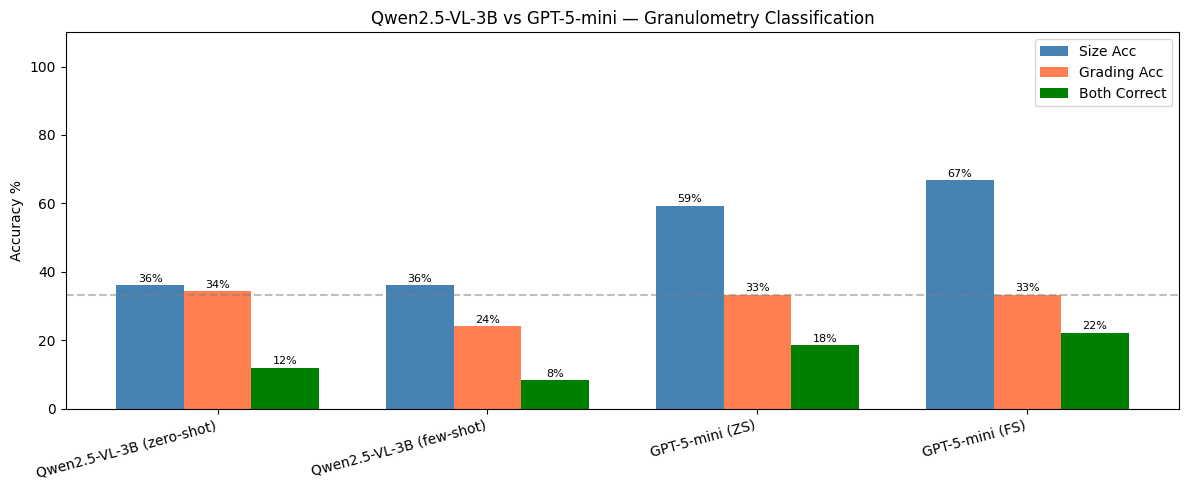

In [44]:
methods = [r['label'] for r in rows]
size_vals = [r['size'] for r in rows]
grad_vals = [r['grading'] for r in rows]
both_vals = [r['both'] for r in rows]

x = np.arange(len(methods))
w = 0.25
fig, ax = plt.subplots(figsize=(12, 5))
b1 = ax.bar(x - w, size_vals, w, label='Size Acc', color='steelblue')
b2 = ax.bar(x, grad_vals, w, label='Grading Acc', color='coral')
b3 = ax.bar(x + w, both_vals, w, label='Both Correct', color='green')
ax.set_xticks(x); ax.set_xticklabels(methods, rotation=15, ha='right')
ax.set_ylabel('Accuracy %'); ax.set_ylim(0, 110)
ax.set_title('Qwen2.5-VL-3B vs GPT-5-mini â€” Granulometry Classification')
ax.legend()
ax.axhline(y=33.3, color='gray', linestyle='--', alpha=0.5, label='Random chance')
for bars in [b1, b2, b3]:
    for bar in bars:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1, f'{bar.get_height():.0f}%', ha='center', fontsize=8)
plt.tight_layout(); plt.show()


## Save Results

In [45]:
for label, s, results in [
    ('frontier-zero-shot', fr_zs_s, fr_zs_results),
    ('frontier-few-shot', fr_fs_s, fr_fs_results),
]:
    fname = f'benchmark_results_{label}.json'
    with open(fname, 'w') as f:
        json.dump({
            'model': f'{DEPLOYMENT} (Azure OpenAI)', 'mode': label, 'phase': 'frontier_baseline',
            'total_images': s['n'], 'json_validity_pct': s['json'],
            'size_accuracy_pct': s['size'], 'grading_accuracy_pct': s['grading'],
            'both_correct_pct': s['both'], 'avg_inference_time_s': s['time'],
            'results': results,
        }, f, indent=2)
    print(f'Saved {fname}')

print(f'\nConclusion:')
print(f'If GPT-5-mini >> Qwen baseline -> use it as teacher for SEAL augmentation in Task 4')
print(f'If GPT-5-mini ~= Qwen baseline -> task may need different approach')


Saved benchmark_results_frontier-zero-shot.json
Saved benchmark_results_frontier-few-shot.json

Conclusion:
If GPT-5-mini >> Qwen baseline -> use it as teacher for SEAL augmentation in Task 4
If GPT-5-mini ~= Qwen baseline -> task may need different approach


# GPT 4.1 Benchmarking

In [76]:
PROMPT_ZS_41 = '''This is a top-down photograph of concrete aggregate particles at GSD = 8.0 pixels per mm.
At this resolution: 8mm = ~64px, 16mm = ~128px, 32mm = ~256px.

Classify on two independent axes:

1. MAX PARTICLE SIZE (8, 16, or 32 mm)
   Find the single largest stone in the image. Estimate its diameter in pixels, divide by 8.0, round to the nearest of: 8, 16, or 32.

2. GRADING (coarse, medium, or fine)
   This follows the DIN 1045 standard grading curves A/B/C for concrete aggregate.
   Grading describes the SHAPE of the particle size distribution curve â€” NOT the absolute particle size.
   For any given max particle size:

   COARSE (curve A / uniformly graded):
   - Most particles are concentrated near the maximum size
   - Very few small particles present
   - Large visible gaps/voids between stones (not filled by smaller material)
   - Surface appears as a single layer of similarly-sized stones
   - Low packing density â€” you can see the background between particles

   MEDIUM (curve B / well-graded):
   - Balanced mix of particle sizes from small to large
   - Some smaller particles fill gaps between larger ones, but not completely
   - Moderate packing density

   FINE (curve C / continuously graded):
   - Wide range of particle sizes present simultaneously
   - Many small particles densely fill ALL gaps between larger stones
   - Very high packing density â€” almost no visible voids or background
   - Surface appears tightly packed, dense, and heterogeneous

   KEY VISUAL TEST: Look at the spaces between the largest stones.
   - If gaps are EMPTY â†’ coarse
   - If gaps are PARTIALLY filled â†’ medium
   - If gaps are COMPLETELY filled with smaller particles â†’ fine

Respond with ONLY a JSON object:
{"max_particle_size_mm": <8|16|32>, "grading": "<coarse|medium|fine>"}'''

PROMPT_FS_REF_41 = '''First image is a reference chart: 3x3 grid of concrete aggregate photographs.

COLUMNS (left to right) = max particle size: 8mm | 16mm | 32mm
ROWS (top to bottom) = grading curve: A (coarse) | B (medium) | C (fine)

This follows DIN 1045 standard grading curves. Grading describes the particle size DISTRIBUTION shape, independent of max size:

ROW A â€” COARSE (uniformly graded):
- Particles are mostly one size, close to the column's max
- Gaps between stones are EMPTY â€” few small particles fill them
- Low packing density, visible voids/background between stones
- Looks like a single layer of similar-sized stones

ROW B â€” MEDIUM (well-graded):
- Balanced mix of sizes
- Gaps between large stones are PARTIALLY filled by smaller ones
- Moderate packing density

ROW C â€” FINE (continuously graded):
- Wide range of sizes present
- Gaps between large stones are COMPLETELY filled by smaller particles
- Very high packing density, almost no visible voids
- Surface looks dense, tightly packed, heterogeneous

CRITICAL VISUAL CUE: Compare row A vs row C in the same column (same max size).
- Row A: you can see gaps/background between the stones
- Row C: no gaps visible â€” small particles fill everything

Study each cell carefully before classifying the next image.'''

PROMPT_FS_QUERY_41 = '''Classify this photograph. GSD = 8.0 px/mm (8mm=~64px, 16mm=~128px, 32mm=~256px).

Compare to the reference grid:
1. COLUMN: What is the largest stone size? Match to 8, 16, or 32mm.
2. ROW: Look at the gaps between the largest stones.
   - Gaps EMPTY, single-size layer â†’ coarse (A)
   - Gaps PARTIALLY filled â†’ medium (B)
   - Gaps COMPLETELY filled, dense packed â†’ fine (C)

Respond with ONLY JSON: {"max_particle_size_mm": <8|16|32>, "grading": "<coarse|medium|fine>"}'''


In [ ]:
# GPT-4.1 Quick Test â€” separate client, same notebook
from openai import AzureOpenAI

client_41 = AzureOpenAI(
    azure_endpoint='https://ether-openai.openai.azure.com/',
    api_key='your-api-key',  # set your key
    api_version='2024-12-01-preview',
)

def call_41_zs(image_b64, prompt):
    resp = client_41.chat.completions.create(
        model='gpt-4.1', max_tokens=256, temperature=0.7,
        messages=[{'role': 'user', 'content': [
            {'type': 'image_url', 'image_url': {'url': f'data:image/jpeg;base64,{image_b64}'}},
            {'type': 'text', 'text': prompt},
        ]}],
    )
    return resp.choices[0].message.content

def call_41_fs(ref_b64, image_b64, ref_prompt, query_prompt):
    resp = client_41.chat.completions.create(
        model='gpt-4.1', max_tokens=256, temperature=0.7,
        messages=[{'role': 'user', 'content': [
            {'type': 'image_url', 'image_url': {'url': f'data:image/png;base64,{ref_b64}'}},
            {'type': 'text', 'text': ref_prompt},
            {'type': 'image_url', 'image_url': {'url': f'data:image/jpeg;base64,{image_b64}'}},
            {'type': 'text', 'text': query_prompt},
        ]}],
    )
    return resp.choices[0].message.content

quick_classes = ['A32', 'B16', 'C8']
quick = [next(e for e in manifest if e['class'] == cls) for cls in quick_classes]

for mode in ['zero-shot', 'few-shot']:
    print(f'\n{"=" * 60}')
    print(f'GPT-4.1 Quick test â€” {mode} (temperature=0)')
    print(f'{"=" * 60}')
    for entry in quick:
        img_path = os.path.join(TEST_DIR, entry['image'])
        img_b64 = encode_image(img_path)
        try:
            if mode == 'zero-shot':
                raw = call_41_zs(img_b64, PROMPT_ZS_41)
            else:
                raw = call_41_fs(ref_b64, img_b64, PROMPT_FS_REF_41, PROMPT_FS_QUERY_41)
        except Exception as e:
            print(f'{entry["class"]:<6} ERROR: {e}')
            continue
        parsed = parse_response(raw)
        gt_s = entry['max_particle_size_mm']; gt_g = entry['grading']
        if parsed:
            ps = parsed.get('max_particle_size_mm'); pg = parsed.get('grading', '').lower()
            if isinstance(ps, str): ps = int(ps) if ps.isdigit() else ps
            sv = 'âœ“' if ps == gt_s else 'âœ—'; gv = 'âœ“' if pg == gt_g else 'âœ—'
            print(f'{entry["class"]:<6} GT: {gt_s}mm {gt_g:<8} Pred: {str(ps)}mm {pg:<10} Size {sv}  Grade {gv}')
        else:
            print(f'{entry["class"]:<6} PARSE FAIL | Raw: {raw[:200]}')
        time.sleep(0.3)



GPT-4.1 Quick test â€” zero-shot (temperature=0)
A32    GT: 32mm coarse   Pred: 16mm medium     Size âœ—  Grade âœ—
B16    GT: 16mm medium   Pred: 16mm medium     Size âœ“  Grade âœ“
C8     GT: 8mm fine     Pred: 8mm fine       Size âœ“  Grade âœ“

GPT-4.1 Quick test â€” few-shot (temperature=0)
A32    GT: 32mm coarse   Pred: 16mm coarse     Size âœ—  Grade âœ“
B16    GT: 16mm medium   Pred: 16mm medium     Size âœ“  Grade âœ“
C8     GT: 8mm fine     Pred: 8mm fine       Size âœ“  Grade âœ“


In [ ]:
# GPT-4.1 Benchmark â€” 108 images, both modes
from openai import AzureOpenAI

client_41 = AzureOpenAI(
    azure_endpoint='https://ether-openai.openai.azure.com/',
    api_key='your-api-key',
    api_version='2024-12-01-preview',
)

def call_41_zs(image_b64, prompt):
    resp = client_41.chat.completions.create(
        model='gpt-4.1', max_tokens=256, temperature=0.7,
        messages=[{'role': 'user', 'content': [
            {'type': 'image_url', 'image_url': {'url': f'data:image/jpeg;base64,{image_b64}'}},
            {'type': 'text', 'text': prompt},
        ]}],
    )
    return resp.choices[0].message.content

def call_41_fs(ref_b64, image_b64, ref_prompt, query_prompt):
    resp = client_41.chat.completions.create(
        model='gpt-4.1', max_tokens=256, temperature=0.7,
        messages=[{'role': 'user', 'content': [
            {'type': 'image_url', 'image_url': {'url': f'data:image/png;base64,{ref_b64}'}},
            {'type': 'text', 'text': ref_prompt},
            {'type': 'image_url', 'image_url': {'url': f'data:image/jpeg;base64,{image_b64}'}},
            {'type': 'text', 'text': query_prompt},
        ]}],
    )
    return resp.choices[0].message.content

def run_41_benchmark(manifest, mode, ref_b64=None):
    results = []; c_size = 0; c_grading = 0; v_json = 0; t_time = 0
    for i, entry in enumerate(manifest):
        img_path = os.path.join(TEST_DIR, entry['image'])
        if not os.path.exists(img_path): continue
        img_b64 = encode_image(img_path)
        t = time.time()
        try:
            if mode == 'zero-shot':
                raw = call_41_zs(img_b64, PROMPT_ZS_41 )
            else:
                raw = call_41_fs(ref_b64, img_b64, PROMPT_FS_REF_41 , PROMPT_FS_QUERY_41 )
        except Exception as e:
            raw = f'ERROR: {e}'
        elapsed = time.time() - t; t_time += elapsed
        parsed = parse_response(raw)
        gt_s = entry['max_particle_size_mm']; gt_g = entry['grading']
        s_ok = False; g_ok = False
        if parsed:
            v_json += 1
            ps = parsed.get('max_particle_size_mm')
            if isinstance(ps, str): ps = int(ps) if ps.isdigit() else None
            if ps == gt_s: s_ok = True; c_size += 1
            if parsed.get('grading', '').lower() == gt_g: g_ok = True; c_grading += 1
        results.append({'image': entry['image'], 'class': entry['class'],
            'gt_size': gt_s, 'gt_grading': gt_g, 'predicted': parsed, 'raw': raw,
            'size_correct': s_ok, 'grading_correct': g_ok, 'valid_json': parsed is not None,
            'time_s': round(elapsed, 2)})
        if (i+1) % 20 == 0:
            n = i+1
            print(f'  [{n}/{len(manifest)}] Size: {c_size}/{n} ({c_size/n*100:.0f}%) | '
                  f'Grading: {c_grading}/{n} ({c_grading/n*100:.0f}%) | JSON: {v_json}/{n}')
        time.sleep(0.25)
    return results, c_size, c_grading, v_json, t_time

# Zero-shot
print('GPT-4.1 zero-shot (temperature=0)...')
r41_zs, s41_zs, g41_zs, j41_zs, t41_zs = run_41_benchmark(manifest, 'zero-shot')
print(f'Done. {len(r41_zs)} images in {t41_zs:.0f}s')

# Few-shot
print('\nGPT-4.1 few-shot (temperature=0)...')
r41_fs, s41_fs, g41_fs, j41_fs, t41_fs = run_41_benchmark(manifest, 'few-shot', ref_b64=ref_b64)
print(f'Done. {len(r41_fs)} images in {t41_fs:.0f}s')

# Save
for label, r, cs, cg, vj, tt in [
    ('gpt41-zero-shot', r41_zs, s41_zs, g41_zs, j41_zs, t41_zs),
    ('gpt41-few-shot', r41_fs, s41_fs, g41_fs, j41_fs, t41_fs),
]:
    n = len(r); both = sum(1 for x in r if x['size_correct'] and x['grading_correct'])
    with open(f'benchmark_results_{label}.json', 'w') as f:
        json.dump({
            'model': 'gpt-4.1 (Azure OpenAI)', 'mode': label, 'phase': 'frontier_baseline',
            'total_images': n, 'json_validity_pct': round(vj/n*100,1),
            'size_accuracy_pct': round(cs/n*100,1), 'grading_accuracy_pct': round(cg/n*100,1),
            'both_correct_pct': round(both/n*100,1), 'avg_inference_time_s': round(tt/n,2),
            'results': r,
        }, f, indent=2)
    print(f'Saved benchmark_results_{label}.json')


GPT-4.1 zero-shot (temperature=0)...
  [20/108] Size: 10/20 (50%) | Grading: 2/20 (10%) | JSON: 20/20
  [40/108] Size: 21/40 (52%) | Grading: 12/40 (30%) | JSON: 40/40
  [60/108] Size: 35/60 (58%) | Grading: 25/60 (42%) | JSON: 60/60
  [80/108] Size: 42/80 (52%) | Grading: 33/80 (41%) | JSON: 80/80
  [100/108] Size: 53/100 (53%) | Grading: 45/100 (45%) | JSON: 100/100
Done. 108 images in 466s

GPT-4.1 few-shot (temperature=0)...
  [20/108] Size: 13/20 (65%) | Grading: 7/20 (35%) | JSON: 20/20
  [40/108] Size: 26/40 (65%) | Grading: 17/40 (42%) | JSON: 40/40
  [60/108] Size: 39/60 (65%) | Grading: 31/60 (52%) | JSON: 60/60
  [80/108] Size: 50/80 (62%) | Grading: 43/80 (54%) | JSON: 80/80
  [100/108] Size: 61/100 (61%) | Grading: 56/100 (56%) | JSON: 100/100
Done. 108 images in 509s
Saved benchmark_results_gpt41-zero-shot.json
Saved benchmark_results_gpt41-few-shot.json



Method                     JSON    Size   Grade    Both    Time
Qwen2.5-VL-3B (ZS)         100%   36.1%   34.3%   12.0%    8.9s
Qwen2.5-VL-3B (FS)         100%   36.1%   24.1%    8.3%    9.4s
GPT-5 (ZS)                 100%   59.3%   33.3%   18.5%   11.9s
GPT-5 (FS)                 100%   66.7%   33.3%   22.2%   15.8s
GPT-4.1 (ZS, t=0)          100%   53.7%   49.1%   31.5%    4.3s
GPT-4.1 (FS, t=0)          100%   62.0%   59.3%   29.6%    4.7s

Random chance: 33.3% for size, 33.3% for grading, 11.1% for both


Per-class SIZE accuracy:
Class  Qwen2.5-VL Qwen2.5-VL      GPT-5      GPT-5    GPT-4.1    GPT-4.1
------------------------------------------------------------------------
A8       1/ 12      1/ 12      9/ 12      4/ 12      3/ 12     10/ 12   
A16     10/ 12      1/ 12     12/ 12      5/ 12     12/ 12     12/ 12   
A32      1/ 12     11/ 12      0/ 12     10/ 12      0/ 12      0/ 12   
B8       2/ 12      1/ 12     11/ 12     10/ 12      7/ 12     11/ 12   
B16      9/ 12      

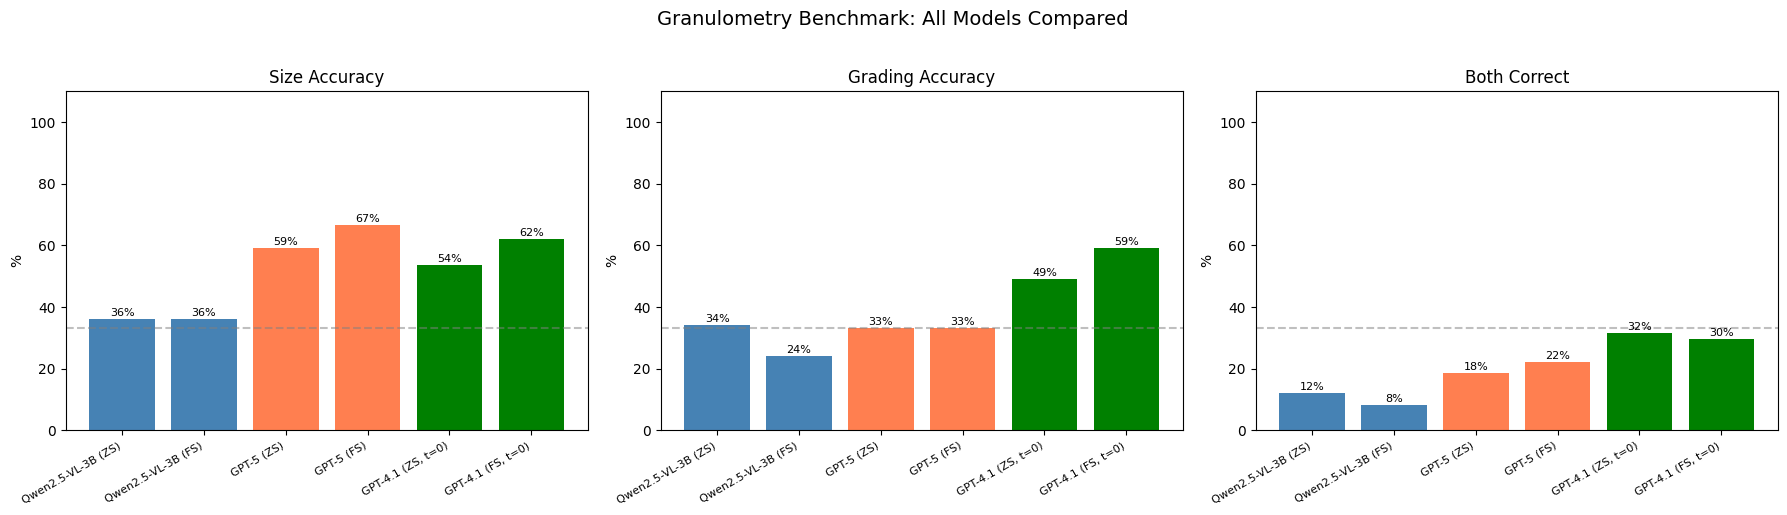

In [82]:
# Compare ALL benchmark results
from collections import defaultdict

files = [
    ('Qwen2.5-VL-3B (ZS)', 'benchmark_results_zero-shot.json'),
    ('Qwen2.5-VL-3B (FS)', 'benchmark_results_few-shot.json'),
    ('GPT-5 (ZS)', 'benchmark_results_frontier-zero-shot.json'),
    ('GPT-5 (FS)', 'benchmark_results_frontier-few-shot.json'),
    ('GPT-4.1 (ZS, t=0)', 'benchmark_results_gpt41-zero-shot.json'),
    ('GPT-4.1 (FS, t=0)', 'benchmark_results_gpt41-few-shot.json'),
]

rows = []
for label, path in files:
    if not os.path.exists(path):
        print(f'{label}: file not found'); continue
    with open(path) as f:
        d = json.load(f)
    rows.append({'label': label, 'json': d['json_validity_pct'], 'size': d['size_accuracy_pct'],
        'grading': d['grading_accuracy_pct'], 'both': d['both_correct_pct'], 'time': d['avg_inference_time_s']})

print(f'\n{"Method":<24} {"JSON":>6} {"Size":>7} {"Grade":>7} {"Both":>7} {"Time":>7}')
print('=' * 60)
for r in rows:
    print(f'{r["label"]:<24} {r["json"]:>5.0f}% {r["size"]:>6.1f}% {r["grading"]:>6.1f}% {r["both"]:>6.1f}% {r["time"]:>6.1f}s')
print(f'\nRandom chance: 33.3% for size, 33.3% for grading, 11.1% for both')

# Per-class breakdown for all models
print(f'\n\nPer-class SIZE accuracy:')
print(f'{"Class":<6}', end='')
for label, _ in files:
    short = label.split('(')[0].strip()[:10]
    print(f' {short:>10}', end='')
print()
print('-' * (6 + 11 * len(files)))

for cls in ['A8','A16','A32','B8','B16','B32','C8','C16','C32']:
    print(f'{cls:<6}', end='')
    for label, path in files:
        if not os.path.exists(path): print(f' {"â€”":>10}', end=''); continue
        with open(path) as f:
            d = json.load(f)
        cr = [r for r in d['results'] if r['class'] == cls]
        sc = sum(1 for r in cr if r['size_correct'])
        print(f' {sc:>3}/{len(cr):>3}', end='   ')
    print()

print(f'\n\nPer-class GRADING accuracy:')
print(f'{"Class":<6}', end='')
for label, _ in files:
    short = label.split('(')[0].strip()[:10]
    print(f' {short:>10}', end='')
print()
print('-' * (6 + 11 * len(files)))

for cls in ['A8','A16','A32','B8','B16','B32','C8','C16','C32']:
    print(f'{cls:<6}', end='')
    for label, path in files:
        if not os.path.exists(path): print(f' {"â€”":>10}', end=''); continue
        with open(path) as f:
            d = json.load(f)
        cr = [r for r in d['results'] if r['class'] == cls]
        gc = sum(1 for r in cr if r['grading_correct'])
        print(f' {gc:>3}/{len(cr):>3}', end='   ')
    print()

# Bar chart
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
labels = [r['label'] for r in rows]
x = np.arange(len(labels))

for idx, (metric, key) in enumerate([('Size Accuracy', 'size'), ('Grading Accuracy', 'grading'), ('Both Correct', 'both')]):
    vals = [r[key] for r in rows]
    colors = ['steelblue','steelblue','coral','coral','green','green'][:len(vals)]
    bars = axes[idx].bar(x, vals, color=colors)
    axes[idx].set_xticks(x); axes[idx].set_xticklabels(labels, rotation=30, ha='right', fontsize=8)
    axes[idx].set_ylabel('%'); axes[idx].set_title(metric); axes[idx].set_ylim(0, 110)
    axes[idx].axhline(y=33.3, color='gray', linestyle='--', alpha=0.5)
    for bar in bars:
        axes[idx].text(bar.get_x()+bar.get_width()/2, bar.get_height()+1, f'{bar.get_height():.0f}%', ha='center', fontsize=8)

plt.suptitle('Granulometry Benchmark: All Models Compared', fontsize=14, y=1.02)
plt.tight_layout(); plt.show()
